# Iterative Optimisation

After initialisation, each iteration of IXPLORE first refits per-user posteriors against the current item models, then refits the item models against the new posterior point estimates. We sweep iteration count $T \in \{0, 1, 2, 5, 10, 20\}$ and the initialisation scheme (PCA vs. random) at the standard sparsity/seed grid, with $\tau^2 = 0.25$ fixed.

**Research questions:**
1. Does iterative alternation between posteriors and item models improve fit and imputation?
2. Does PCA initialisation reduce the number of iterations until convergence?

In [1]:
import sys; sys.path.insert(0, "../..")
import logging; logging.getLogger("ixplore").setLevel(logging.WARNING)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATASET = "smartvote_2023"
RESULTS_DIR = Path(f"../../results/{DATASET}/iteration_effect")

SIGMA_DEFAULT = 0.25
INITS = ["pca", "random"]

train = pd.read_csv(RESULTS_DIR / "train_metrics.csv")
test = pd.read_csv(RESULTS_DIR / "test_metrics.csv")
print(f"train: {train.shape}, test: {test.shape}")
print(f"train cols: {list(train.columns)}")

train: (1152, 15), test: (1152, 13)
train cols: ['fit_mae', 'fit_accuracy', 'fit_rmse', 'impute_mae', 'impute_accuracy', 'impute_rmse', 'spread', 'boundary', 'distortion_mean', 'distortion_std', 'sigma', 'init', 'iteration', 'sparsity', 'seed']


## Does PCA initialisation reduce iterations until convergence?

Compare PCA vs. random initialisation across iterations at the default prior. Fit MAE is at `FIT_SPARSITIES`; impute MAE is averaged over `IMPUTE_SPARSITIES`.

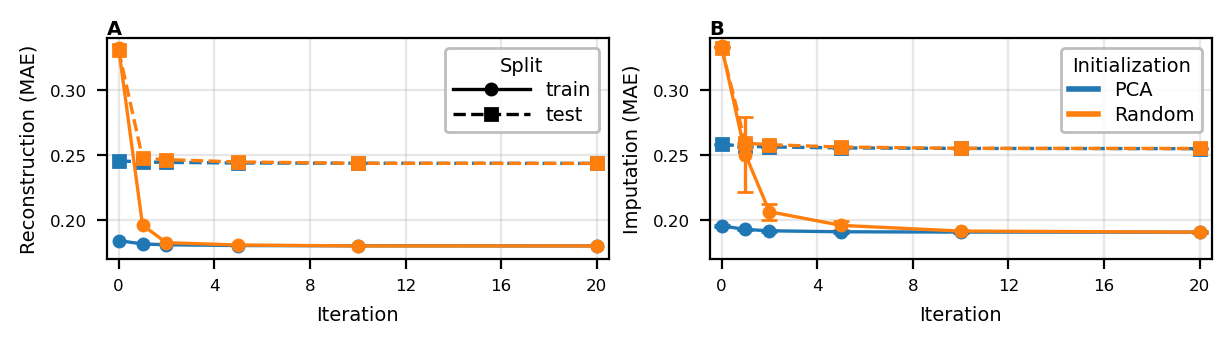

In [2]:
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter, MultipleLocator, MaxNLocator
from src.visualization import figsize, apply_defaults

apply_defaults()

# Sparsity sets to aggregate over per panel.
FIT_SPARSITIES = [0.0]              # fit MAE: u = 0 only
IMPUTE_SPARSITIES = [0.6] # impute MAE: undefined at u = 0

def aggregate(df, metric, sparsities):
    """Average per (init, iteration, seed) over the given sparsities, then take
    mean and std across seeds. Returns one row per (init, iteration)."""
    sub = df[(df["sigma"] == SIGMA_DEFAULT) & (df["sparsity"].isin(sparsities))]
    per_seed = sub.groupby(["init", "iteration", "seed"])[metric].mean().reset_index()
    return per_seed.groupby(["init", "iteration"])[metric].agg(["mean", "std"]).reset_index()

def sparsity_label(sparsities):
    if len(sparsities) == 1:
        return f"$u={sparsities[0]:g}$"
    return "$u\\in\\{" + ",".join(f"{s:g}" for s in sparsities) + "\\}$"

init_colors = {"pca": "C0", "random": "C1"}
init_labels = {"pca": "PCA", "random": "Random"}

fig, axes = plt.subplots(1, 2, figsize=figsize(width_frac=1.0, aspect=0.26), sharex=True, sharey=True)
panels = [
    ("fit_mae", "Reconstruction", FIT_SPARSITIES),
    ("impute_mae", "Imputation", IMPUTE_SPARSITIES),
]

for ax, (metric, panel_label, sparsities) in zip(axes, panels):
    for init in INITS:
        tr_sub = aggregate(train, metric, sparsities)
        tr_sub = tr_sub[tr_sub["init"] == init]
        te_sub = aggregate(test, metric, sparsities)
        te_sub = te_sub[te_sub["init"] == init]
        ax.errorbar(tr_sub["iteration"], tr_sub["mean"], yerr=tr_sub["std"],
                    marker="o", capsize=3, color=init_colors[init], linestyle="-")
        ax.errorbar(te_sub["iteration"], te_sub["mean"], yerr=te_sub["std"],
                    marker="s", capsize=3, color=init_colors[init], linestyle="--")
    ax.set_xlabel("Iteration")
    ax.set_xlim(-0.5, 20.5)
    ax.set_ylim(0.17, 0.34)
    ax.set_ylabel(f"{panel_label} (MAE)")
    # ax.yaxis.set_major_locator(MultipleLocator(0.05))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.xaxis.set_major_locator(MultipleLocator(4))
    ax.yaxis.set_tick_params(labelleft=True)
    ax.grid(alpha=0.3)

style_handles = [
    Line2D([0], [0], color="black", linestyle="-", marker="o", label="train"),
    Line2D([0], [0], color="black", linestyle="--", marker="s", label="test"),
]
color_handles = [Line2D([0], [0], color=init_colors[i], lw=2, label=init_labels[i]) for i in INITS]

axes[0].legend(handles=style_handles, loc="best", title="Split",
               handlelength=4, labelspacing=0.3)
axes[1].legend(handles=color_handles, loc="best", title="Initialization", 
               handlelength=1.5, labelspacing=0.3)
fig.text(-0,1, 'A', va='bottom', ha='left', weight='bold', transform=axes[0].transAxes)
fig.text(-0,1, 'B', va='bottom', ha='left', weight='bold', transform=axes[1].transAxes)
fig.tight_layout(pad=0.2, rect=[0, 0, 1, 0.94], w_pad=0.7)
fig.savefig(f"../../figures/iteration_effect_{DATASET}.pdf")
plt.show()


In [3]:
# Quantify the gap: |mae(pca) - mae(random)| per iteration, for fit and impute.
def init_gap(df, metric, sparsities):
    sub = df[(df["sigma"] == SIGMA_DEFAULT) & (df["sparsity"].isin(sparsities))]
    grp = sub.groupby(["init", "iteration"])[metric].mean().unstack("init")
    grp["gap"] = (grp["random"] - grp["pca"]).round(4)
    return grp

print("Train fit\n", init_gap(train, "fit_mae", FIT_SPARSITIES))
print("\nTest fit\n", init_gap(test, "fit_mae", FIT_SPARSITIES))
print("\nTrain impute\n", init_gap(train, "impute_mae", IMPUTE_SPARSITIES))
print("\nTest impute\n", init_gap(test, "impute_mae", IMPUTE_SPARSITIES))


Train fit
 init          pca  random     gap
iteration                        
0          0.1845  0.3326  0.1481
1          0.1819  0.1963  0.0144
2          0.1813  0.1829  0.0016
5          0.1807  0.1811  0.0004
10         0.1805  0.1804 -0.0001
20         0.1804  0.1804  0.0000

Test fit
 init          pca  random     gap
iteration                        
0          0.2459  0.3310  0.0851
1          0.2450  0.2479  0.0029
2          0.2447  0.2468  0.0021
5          0.2442  0.2450  0.0008
10         0.2440  0.2440  0.0000
20         0.2439  0.2439  0.0000

Train impute
 init           pca   random     gap
iteration                          
0          0.19586  0.33392  0.1381
1          0.19308  0.25070  0.0576
2          0.19206  0.20674  0.0147
5          0.19128  0.19622  0.0049
10         0.19106  0.19184  0.0008
20         0.19098  0.19100  0.0000

Test impute
 init           pca   random     gap
iteration                          
0          0.25854  0.33302  0.0745
1        